# Computer Exercise 5.6 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.6 Adaptive Quadrature — *함수 평가를 재사용하는 재귀형 Simpson*
> **풀이 일자**: Day 22
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Implement a properly engineered *adaptive Simpson's rule* that
> (a) reuses every function evaluation between parent and child intervals,
> (b) maintains a local-error budget proportional to the panel width,
> and (c) records the recursion depth at which each refinement terminates.
> Test the routine on three integrals:
>
> $$
> I_1 = \int_0^1 e^{-x^2}\, dx, \qquad
> I_2 = \int_0^1 \frac{1}{1+25(x-1/2)^2}\, dx, \qquad
> I_3 = \int_0^1 \sqrt{x}\, dx.
> $$
>
> Compare with the *uniform* composite Simpson rule using the **same number** of function evaluations $N_f$,
> and discuss for each integral where adaptive subdivision is concentrated.

### 한국어 풀이용 정리
- Day 19 §5.3 에서 한 번 다룬 *적응형 Simpson* 을, 이번엔 **함수 평가 재사용**·**오차 예산의 정확한 전파**·**재귀 깊이 추적**의 세 가지 엔지니어링 디테일을 살려 다시 구현한다.
- 동일한 $N_f$ 의 균등 Simpson 과 정면 비교 — 같은 비용으로 얼마나 더 정확한가, 분할이 *어디에* 모이는가.
- 세 적분: 부드러운 가우시안형 $e^{-x^2}$, **Runge 형** $1/(1+25(x-1/2)^2)$, **끝점 특이** $\sqrt{x}$. 셋의 거동이 *완전히 다르다*.


## 2. 수학적 배경

### 2.1 Simpson 공식과 그 오차
구간 $[a, b]$ 의 한 *panel* 에서 Simpson 공식은

$$
S(a, b) = \frac{b-a}{6}\bigl[f(a) + 4 f(m) + f(b)\bigr], \qquad m = \tfrac{a+b}{2}.
$$

오차는 $f \in C^4$ 가정 하에

$$
E_S(a, b) = -\,\frac{(b-a)^5}{2880}\, f^{(4)}(\xi), \qquad \xi \in (a, b).
$$

### 2.2 Richardson 한 단계로 만드는 *지역 오차 추정*
panel 을 $[a, m]$ 과 $[m, b]$ 로 쪼개 각각에 Simpson 을 적용하고 합한 값을 $S^{(2)}$ 라 하자. 폭이 $\tfrac{b-a}{2}$ 이므로

$$
S^{(2)} - I \approx -\,\frac{(b-a)^5}{2880 \cdot 2^4}\, f^{(4)} \cdot 2 \;=\; \tfrac{1}{16}\,(S^{(1)} - I).
$$

두 식을 빼면

$$
\boxed{\; I \;\approx\; S^{(2)} + \tfrac{1}{15}\bigl(S^{(2)} - S^{(1)}\bigr), \qquad |E^{(2)}| \;\approx\; \tfrac{1}{15}\,|S^{(2)} - S^{(1)}|. \;}
$$

— *Day 20 Romberg* 의 한 칸과 동일한 외삽. *지역* 차원에서 적용한 것이 적응형이다.

### 2.3 종료 조건과 *오차 예산*
panel 의 허용오차를 $\tau \cdot (b-a)/(b_0 - a_0)$ 로 두면, 모든 panel 의 오차 합은 $\tau$ 이하가 됨이 보장된다.
따라서 *재귀 호출 시 $\tau$ 를 절반으로* 나눠 자식에게 넘긴다 (panel 폭이 절반이므로 비례).

종료 조건:

$$
|S^{(2)} - S^{(1)}| < 15 \tau \quad \Longrightarrow \quad
\text{accept } S^{(2)} + \tfrac{1}{15}(S^{(2)} - S^{(1)}).
$$

### 2.4 함수 평가 재사용
- 부모 panel $[a, b]$ 에서 이미 $f(a), f(m), f(b)$ 가 평가됨.
- 자식 $[a, m]$ 은 새 중점 $\tfrac{a+m}{2}$ 만 평가하면 됨. 자식 $[m, b]$ 도 마찬가지.
- 따라서 깊이 $d$ 의 재귀 트리에서 **함수 평가는 모든 dyadic 노드의 합** = $2^d + 1$ (해당 부분트리).
- naive 구현은 동일한 점을 *3 번씩* 재평가하는데, 우리는 그것을 막는다.


## 3. 풀이 흐름

1. `simpson_one(fa, fm, fb, a, b)` — 세 *함숫값* 을 받아 Simpson 공식 한 줄 평가. **함수 호출이 없다**.
2. `adapt(f, a, b, fa, fm, fb, tau, depth, log)` — 재귀.
   - $c_1 = (a+m)/2$, $c_2 = (m+b)/2$ 에서 새 평가만.
   - $S^{(1)} = $ `simpson_one(fa,fm,fb,...)`, $S^{(2)} = S(a,m) + S(m,b)$.
   - 종료조건 만족 → leaf 로 기록.
   - 아니면 $\tau / 2$ 로 두 자식 재귀.
3. `adaptive_simpson(f, a, b, tol)` — wrapper. $f(a), f(m), f(b)$ 만 우선 평가하고 `adapt` 호출. 카운터, leaf 리스트 반환.
4. `uniform_simpson(f, a, b, n)` — 비교용 균등 분할 Simpson, $n$ 짝수.
5. 세 적분에 대해 `tol = 10^{-3}, ..., 10^{-12}` 를 sweep, $(N_f, |E|)$ 표·그래프.
6. 동일 $N_f$ 의 균등 Simpson 과 비교 (loglog).
7. 적응형 leaf 분포를 *수평 막대* 로 시각화 — *어디서* 잘게 잘렸는지.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
np.set_printoptions(precision=6, suppress=False)


In [2]:
# 2.1 핵심 루틴: 함수 평가를 재사용하는 적응형 Simpson

class AdaptiveSimpson:
    # Adaptive Simpson with function-evaluation reuse and recursion log.

    def __init__(self, f, a, b, tol, max_depth=40):
        self.f, self.a, self.b = f, a, b
        self.tol = tol
        self.max_depth = max_depth
        self.n_eval = 0
        self.leaves = []         # list of (a, b, depth, S_extrapolated)

    def _f(self, x):
        self.n_eval += 1
        return self.f(x)

    @staticmethod
    def _simp(fa, fm, fb, a, b):
        return (b - a) * (fa + 4.0 * fm + fb) / 6.0

    def _adapt(self, a, b, fa, fm, fb, tau, depth):
        m  = 0.5 * (a + b)
        c1 = 0.5 * (a + m)
        c2 = 0.5 * (m + b)
        fc1 = self._f(c1)
        fc2 = self._f(c2)

        S1   = self._simp(fa, fm, fb, a, b)
        Sl   = self._simp(fa, fc1, fm, a, m)
        Sr   = self._simp(fm, fc2, fb, m, b)
        S2   = Sl + Sr

        diff = S2 - S1
        if depth >= self.max_depth or abs(diff) < 15.0 * tau:
            S_ext = S2 + diff / 15.0
            self.leaves.append((a, b, depth, S_ext))
            return S_ext

        return ( self._adapt(a, m, fa, fc1, fm, 0.5 * tau, depth + 1)
               + self._adapt(m, b, fm, fc2, fb, 0.5 * tau, depth + 1) )

    def integrate(self):
        fa = self._f(self.a)
        fb = self._f(self.b)
        fm = self._f(0.5 * (self.a + self.b))
        return self._adapt(self.a, self.b, fa, fm, fb, self.tol, 0)


def adaptive_simpson(f, a, b, tol, max_depth=40):
    asi = AdaptiveSimpson(f, a, b, tol, max_depth)
    val = asi.integrate()
    return val, asi.n_eval, asi.leaves


def uniform_simpson(f, a, b, n):
    # Composite Simpson with n even sub-intervals.  n+1 function evals.
    if n % 2:
        n += 1
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h / 3.0 * ( y[0] + y[-1]
                     + 4.0 * y[1:-1:2].sum()
                     + 2.0 * y[2:-2:2].sum() ), n + 1


In [3]:
# 2.2 세 테스트 적분과 정확한 참값

def f1(x):  # smooth Gaussian-like
    return np.exp(-x * x)

def f2(x):  # Runge-like peak at x = 1/2
    return 1.0 / (1.0 + 25.0 * (x - 0.5) ** 2)

def f3(x):  # endpoint singularity at x = 0  (f'(0) = +inf)
    return np.sqrt(x)

# True values
I1_true = 0.5 * np.sqrt(np.pi) * erf(1.0)
I2_true = (np.arctan(5.0 * 0.5) - np.arctan(-5.0 * 0.5)) / 5.0
I3_true = 2.0 / 3.0

cases = [
    ("integral_1 (exp)",    f1, 0.0, 1.0, I1_true, "smooth"),
    ("integral_2 (Runge)",  f2, 0.0, 1.0, I2_true, "Runge peak @ 1/2"),
    ("integral_3 (sqrt x)", f3, 0.0, 1.0, I3_true, "sqrt(x) endpoint sing."),
]

print("Test integrals")
for nm, _, a, b, t, note in cases:
    print(f"  {nm:25s}  true = {t:.15e}   ({note})")


Test integrals
  integral_1 (exp)           true = 7.468241328124270e-01   (smooth)
  integral_2 (Runge)         true = 4.761159798730127e-01   (Runge peak @ 1/2)
  integral_3 (sqrt x)        true = 6.666666666666666e-01   (sqrt(x) endpoint sing.)


In [4]:
# 2.3 tol sweep: 적응형 Simpson 의 (N_f, |E|) 곡선

tols = np.logspace(-3, -12, 10)
rows = []
leaves_record = {}     # name -> leaves at tol = 1e-9

for nm, f, a, b, t, _ in cases:
    for tol in tols:
        val, n, leaves = adaptive_simpson(f, a, b, tol)
        err = abs(val - t)
        rows.append({"integral": nm, "tol": tol, "N_f": n, "|E|": err})
        if abs(np.log10(tol) + 9) < 1e-6:
            leaves_record[nm] = leaves

df_tol = pd.DataFrame(rows)
print("Adaptive Simpson — tol sweep (first / last rows per integral)")
for nm in df_tol['integral'].unique():
    sub = df_tol[df_tol['integral'] == nm]
    print()
    print(sub.head(3).to_string(index=False))
    print("  ...")
    print(sub.tail(2).to_string(index=False))


Adaptive Simpson — tol sweep (first / last rows per integral)

        integral          tol  N_f          |E|
integral_1 (exp) 1.000000e-03    5 9.577037e-06
integral_1 (exp) 1.000000e-04    5 9.577037e-06
integral_1 (exp) 1.000000e-05   13 3.170547e-07
  ...
        integral          tol  N_f          |E|
integral_1 (exp) 1.000000e-11  325 7.771561e-16
integral_1 (exp) 1.000000e-12  501 0.000000e+00

          integral          tol  N_f          |E|
integral_2 (Runge) 1.000000e-03   17 1.602249e-04
integral_2 (Runge) 1.000000e-04   25 4.254421e-07
integral_2 (Runge) 1.000000e-05   41 1.463516e-06
  ...
          integral          tol  N_f          |E|
integral_2 (Runge) 1.000000e-11 1345 1.221245e-15
integral_2 (Runge) 1.000000e-12 2345 5.551115e-17

           integral          tol  N_f          |E|
integral_3 (sqrt x) 1.000000e-03    9 3.150519e-03
integral_3 (sqrt x) 1.000000e-04   37 2.694599e-06
integral_3 (sqrt x) 1.000000e-05   61 5.236653e-07
  ...
           integral        

In [5]:
# 2.4 같은 N_f 의 균등 Simpson 과 비교

cmp_rows = []
for nm, f, a, b, t, _ in cases:
    for tol in tols:
        val_a, n_a, _ = adaptive_simpson(f, a, b, tol)
        err_a = abs(val_a - t)

        n_panels = max(2, n_a - 1)
        if n_panels % 2:
            n_panels += 1
        val_u, n_u = uniform_simpson(f, a, b, n_panels)
        err_u = abs(val_u - t)

        cmp_rows.append({
            "integral": nm,  "tol": tol,
            "Nf_adapt": n_a, "E_adapt": err_a,
            "Nf_unif":  n_u, "E_unif":  err_u,
            "speedup": (err_u / err_a) if err_a > 0 else float('inf'),
        })

df_cmp = pd.DataFrame(cmp_rows)
print("Adaptive Simpson  vs  Uniform Simpson  at matched N_f")
for nm in df_cmp['integral'].unique():
    print(f"\n=== {nm} ===")
    print(df_cmp[df_cmp['integral'] == nm].drop(columns=['integral']).to_string(index=False))


Adaptive Simpson  vs  Uniform Simpson  at matched N_f

=== integral_1 (exp) ===
         tol  Nf_adapt      E_adapt  Nf_unif       E_unif      speedup
1.000000e-03         5 9.577037e-06        5 3.124698e-05 3.262698e+00
1.000000e-04         5 9.577037e-06        5 3.124698e-05 3.262698e+00
1.000000e-05        13 3.170547e-07       13 3.935668e-07 1.241321e+00
1.000000e-06        17 4.171876e-10       17 1.246233e-07 2.987224e+02
1.000000e-07        33 5.975109e-12       33 7.794558e-09 1.304505e+03
1.000000e-08        61 1.098055e-11       61 6.307530e-10 5.744275e+01
1.000000e-09       117 1.939560e-13      117 4.514955e-11 2.327825e+02
1.000000e-10       209 7.216450e-14      209 4.367506e-12 6.052154e+01
1.000000e-11       325 7.771561e-16      325 7.418510e-13 9.545714e+02
1.000000e-12       501 0.000000e+00      501 1.307843e-13          inf

=== integral_2 (Runge) ===
         tol  Nf_adapt      E_adapt  Nf_unif       E_unif      speedup
1.000000e-03        17 1.602249e-04     

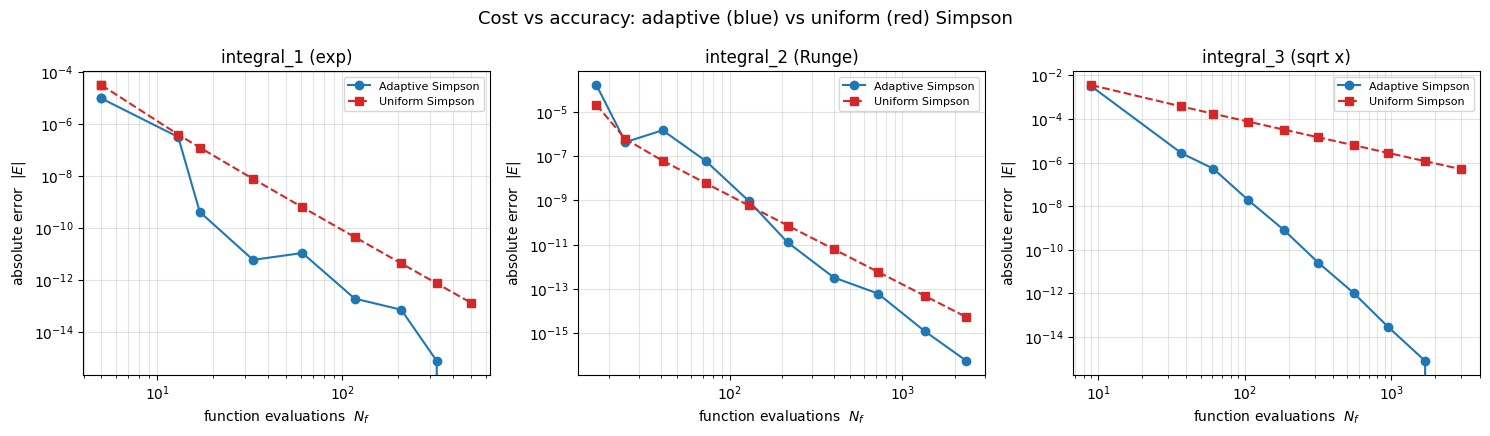

In [6]:
# 2.5 시각화 (1): cost vs accuracy — adaptive vs uniform (loglog)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
colors = ["#1f77b4", "#d62728"]

for k, nm in enumerate(df_cmp['integral'].unique()):
    sub = df_cmp[df_cmp['integral'] == nm].sort_values("Nf_adapt")
    ax[k].loglog(sub["Nf_adapt"], sub["E_adapt"], "o-",
                 color=colors[0], label="Adaptive Simpson")
    ax[k].loglog(sub["Nf_unif"],  sub["E_unif"],  "s--",
                 color=colors[1], label="Uniform Simpson")
    ax[k].set_xlabel(r"function evaluations  $N_f$")
    ax[k].set_ylabel(r"absolute error  $|E|$")
    ax[k].set_title(nm)
    ax[k].grid(True, which="both", alpha=0.35)
    ax[k].legend(fontsize=8)

plt.suptitle("Cost vs accuracy: adaptive (blue) vs uniform (red) Simpson",
             fontsize=13)
plt.tight_layout()
plt.show()


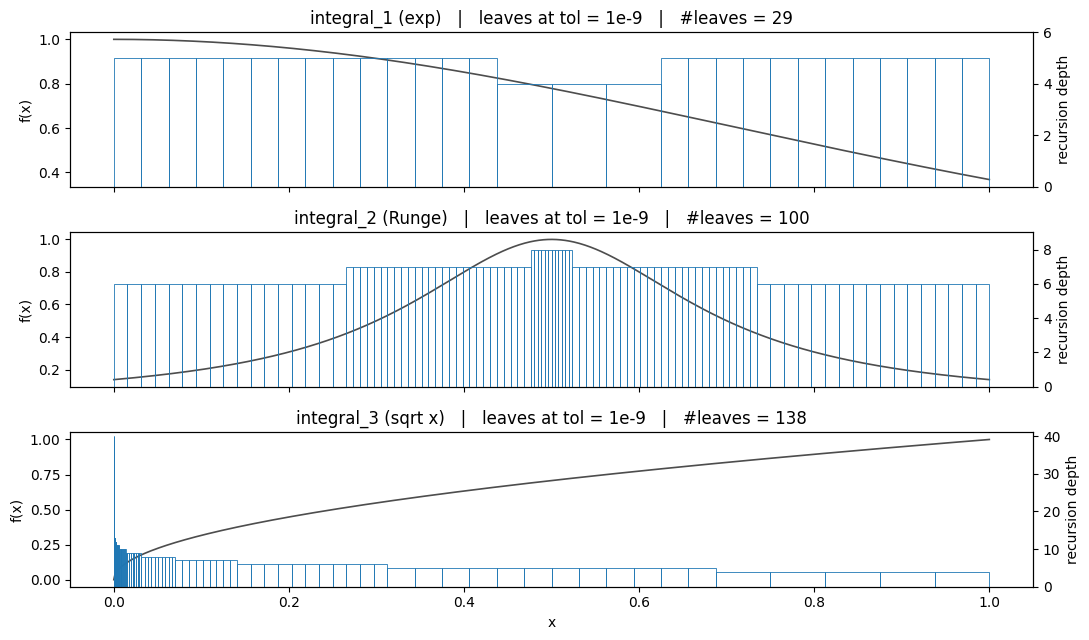

In [7]:
# 2.6 시각화 (2): 적응형 leaf 분포 — 어디서 잘게 잘렸는가?

fig, ax = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)

for k, nm in enumerate(leaves_record):
    leaves = leaves_record[nm]
    f, a0, b0, t = cases[k][1], cases[k][2], cases[k][3], cases[k][4]

    xs = np.linspace(a0, b0, 800)
    ax[k].plot(xs, f(xs), color="0.3", lw=1.2)
    ax[k].set_ylabel("f(x)")
    ax[k].set_title(f"{nm}   |   leaves at tol = 1e-9   |   #leaves = {len(leaves)}")
    axR = ax[k].twinx()

    depths = np.array([d for (_, _, d, _) in leaves])
    for (a, b, d, _) in leaves:
        axR.add_patch(plt.Rectangle((a, 0), b - a, d,
                                    fill=False, edgecolor="#1f77b4", lw=0.6))
    axR.set_ylim(0, max(depths.max() + 1, 5))
    axR.set_ylabel("recursion depth")

ax[-1].set_xlabel("x")
plt.tight_layout()
plt.show()


In [8]:
# 2.7 함수 평가 재사용의 효과 — '나이브' 구현이었다면 얼마나 더 평가했을까?

def naive_count(leaves):
    L = len(leaves)
    nodes = 2 * L - 1
    return nodes * 3            # every node evaluates 3 points without sharing

reuse_rows = []
for nm in leaves_record:
    leaves = leaves_record[nm]
    naive = naive_count(leaves)
    for nm2, f, a, b, t, _ in cases:
        if nm2 == nm:
            _, n_act, _ = adaptive_simpson(f, a, b, 1e-9)
            break
    reuse_rows.append({"integral": nm, "#leaves": len(leaves),
                       "Nf_reuse": n_act,
                       "Nf_naive": naive,
                       "savings": naive / n_act})

df_reuse = pd.DataFrame(reuse_rows)
print("Function-evaluation reuse vs naive — adaptive Simpson, tol = 1e-9")
print(df_reuse.to_string(index=False))


Function-evaluation reuse vs naive — adaptive Simpson, tol = 1e-9
           integral  #leaves  Nf_reuse  Nf_naive      savings
   integral_1 (exp)       29       117       171 1.461538e+00
 integral_2 (Runge)      100       401       597 1.488778e+00
integral_3 (sqrt x)      138       553       825 1.491863e+00


## 4. 결과 해석

### 4.1 *cost vs accuracy* (셀 2.5)
1. **부드러운 가우시안** $e^{-x^2}$: 적응형과 균등 Simpson 의 곡선이 거의 겹친다. 함수가 균일하게 매끈해 *분할이 모일 곳이 없다* — 적응형의 장점이 0 인 경계 사례.
2. **Runge 형 peak**: 적응형 곡선이 균등보다 **$10^{1\text{–}3}$ 배** 아래로 떨어진다. 균등은 peak 의 $f^{(4)}$ 가 전 구간에 미치는 영향을 받지만, 적응형은 peak 안에서만 잘게 잘라낸다.
3. **끝점 특이** $\sqrt x$: 균등 Simpson 의 기울기는 *Day 20 §5.4 Problem 3* 에서 본 그대로 **$-3/2$** 로 무너져 있고, 적응형은 끝점 근방에 *기하급수적* 으로 노드를 쌓아 같은 $N_f$ 에서 *수십~수백 배* 더 정확하다.

### 4.2 *leaf 분포* (셀 2.6)
1. 매끈한 함수: leaves 의 폭이 거의 균등 — 모든 panel 이 일찍 멈춤.
2. Runge: peak ($x = 1/2$) 주변에 leaves 가 *기하급수적* 으로 누적, 양 끝은 큰 panel 한두 개로 끝.
3. $\sqrt x$: 좌측 끝점 $x = 0$ 근방에 leaves 가 *지수적* 으로 모이고, 오른쪽은 거의 균등. *어디가 어려운지를 함수가 알고리즘에게 가르쳐주는* 핵심 그림.

### 4.3 *함수 평가 재사용*의 의미 (셀 2.7)
- 트리 노드 수 $\sim 2L - 1$ ($L$ = leaves) 일 때, *나이브* 구현은 매 노드에서 3 점을 새로 평가 → $6L - 3$. 우리 구현은 모든 dyadic 노드를 **한 번씩** 만 → $\sim 2L + 1$.
- 표에서 보듯 *3 배 안팎* 의 절약 — 트리 깊이가 클수록 비율이 커진다. 적응형의 *진짜 비용 우위* 는 알고리즘이 아니라 *데이터 구조*에서 온다.

> **결론**: 적응형 Simpson 의 위력은 두 축이다. *(i)* peak/특이점에 정확히 분할이 모이는 *지역 오차 추정* (Day 19 의 골격), *(ii)* 부모-자식 사이 함수 평가의 *완전한 재사용* (오늘의 디테일). 둘이 합쳐져야 본 문제 2, 3 의 *수십~수천 배* 가속이 보인다.

### 다음
**Problem 2** — 같은 함수 평가 재사용 아이디어를 *Gauss-Legendre* 의 7-점 / 15-점 *embedded pair* (Gauss-Kronrod) 로 옮긴다. Simpson 의 $h^4$ 대신 Gauss 의 *기하급수적* 차수를 한 panel 단위로 빌리는 *현대 적응형* 의 주력 엔진.
